# Step 1 - Exploratory Data Analysis (EDA): Adult / Census Income

**Goal:** Predict whether an individual's annual income is **> \$50K** based on census features.  
**Type:** Binary classification (**Class 1 → >50K**, **Class 0 → ≤50K**).

**Step 1 (Data Understanding & Exploration)**.
We load the original dataset, understand its structure, visualize distributions and relationships, and summarize findings.  
Each step includes a short justification and/or **what we learned** (result/interpretation).

In [1]:
# 1) Imports and settings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the dataset

We read from the original `adult.data` file and apply the correct column names from the dataset description.  
We also treat `'?'` as missing values and trim leading spaces so categories are clean.

In [2]:
cols = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-s', 'hours-per-week', 'native-country', 'income'
]

# Adjust the path if needed to match your environment
df = pd.read_csv('./data/adult.data', header=None, names=cols, na_values='?', skipinitialspace=True)

print('Shape:', df.shape)
df.head(10)

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


**Result:** We have a dataframe with 32,561 rows x 15 columns (14 features + 1 target).

## 2. Structure & Missing values
We inspect types, non-null counts, and which columns contain missing values.

In [3]:
df.info()
print('\nMissing values per column:')
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Missing values per column:
age                  0
workclass         1836
fnlwgt             

**Why:** Understanding dtypes and missing values helps us determine the preprocessing plan, so either imputation/deletion, encoding, etc.
**Result:** Missing values appear mainly in **workclass (~5.6%)**, **occupation (~5.7%)**, and **native-country (~1.8%)**.

## 3. Cardinality (Unique Values)
We check how many unique values each column has.

In [4]:
df.nunique().sort_values(ascending=False)

fnlwgt            21648
capital-gain        119
hours-per-week       94
capital-loss         92
age                  73
native-country       41
education            16
education-num        16
occupation           14
workclass             8
marital-status        7
relationship          6
race                  5
sex                   2
income                2
dtype: int64

**Why:** High-cardinality categoricals can complicate encoding and model capacity.
**Result:** Categorical columns like `occupation`, `workclass`, and `native-country` have multiple categories but are manageable.

## 4. Target Distribution (Class Balance)
We examine the class balance for the target `income`.

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Percentage distribution:
income
<=50K    75.92
>50K     24.08
Name: count, dtype: float64


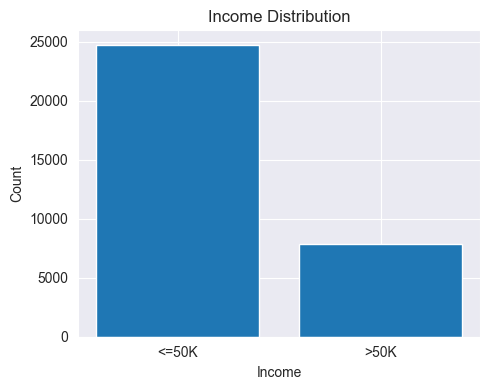

In [5]:
target_counts = df['income'].value_counts().sort_index()
print(target_counts)
print('\nPercentage distribution:')
print(round(target_counts / len(df) * 100, 2))

plt.figure(figsize=(5,4))
plt.bar(target_counts.index, target_counts.values)
plt.title('Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Why:** Class imbalance affects metric choice and modeling strategies (e.g., class weights).
**Result:** Almost **76% ≤50K** and **24% >50K** so = imbalanced classification.

## 5. Descriptive Statistics (Numerical)
We compute summary statistics to understand central tendency, spread, and potential outliers.

In [6]:
desc = df.describe()
desc

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


**Result (high level):**
- **age** ~38.6 (17–90), **hours-per-week** ~40.4 (1–99) = realistic working patterns.
- **education-num** centers ~10 with max 16 = higher values often imply higher income.
- **capital-gain/loss** are very right-skewed with many zeros = informative but sparse.
- **fnlwgt** is a census weight = not predictive, so we plan to drop it later.

## 6. Distributions - Numerical Features
Histograms show the shape (skewness...) of each numeric column.

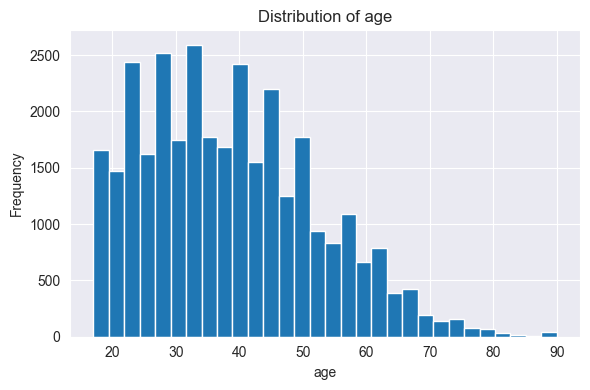

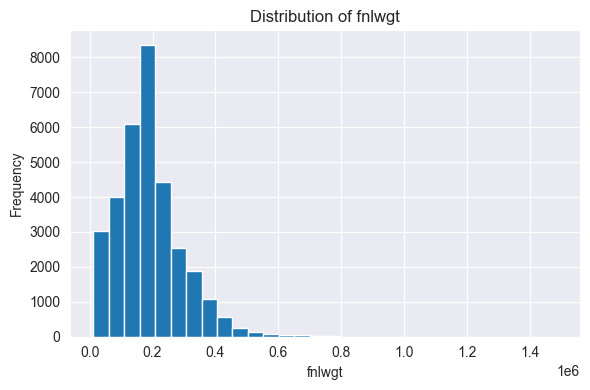

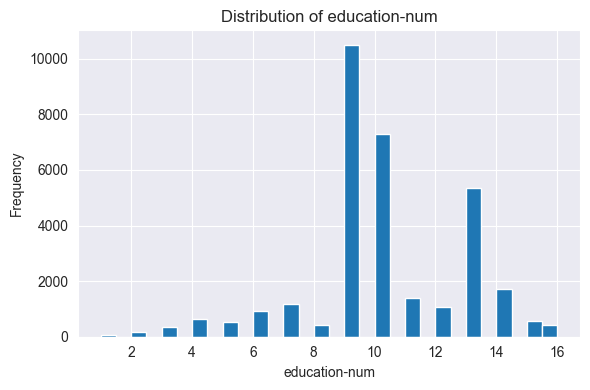

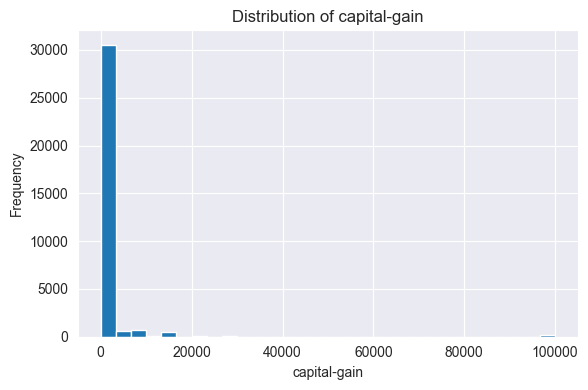

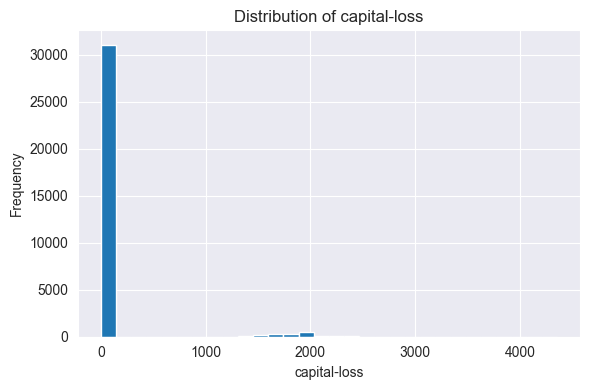

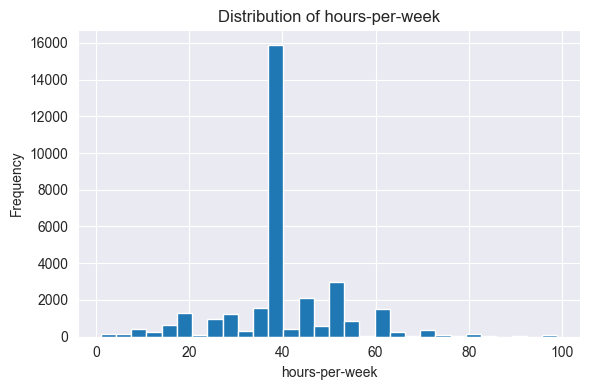

In [7]:
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

**Why:** Distributions guide transformations (like log for skew) and scaling choices.
**Result:** `age` ~bell-shaped  `hours-per-week` peaks at 40–45; `capital-gain/loss` are sparse with long right tails.

## 7. Outliers - Boxplots
We look for extreme values that may need robust scaling or capping.

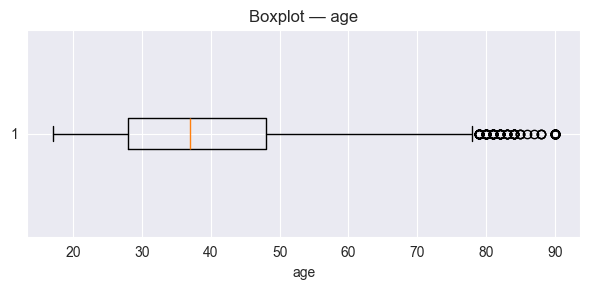

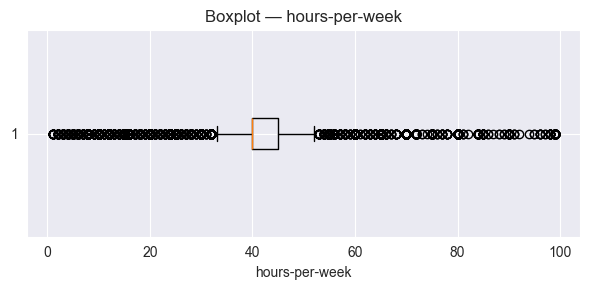

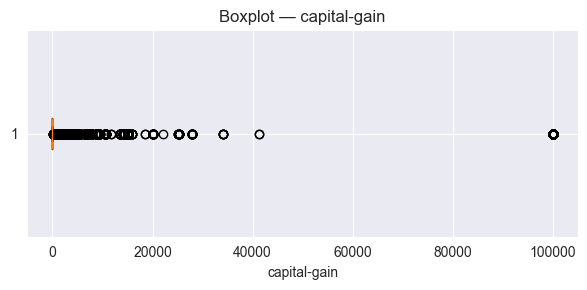

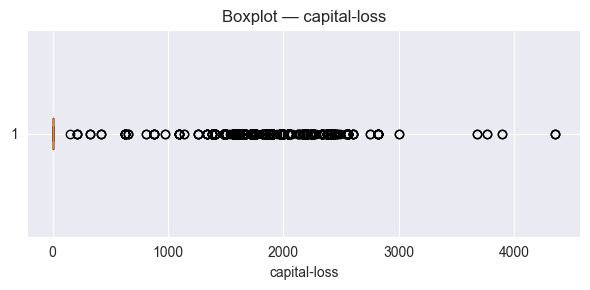

In [8]:
for col in ['age', 'hours-per-week', 'capital-gain', 'capital-loss']:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot — {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

**Why:** Outliers can distort model training - knowing them can help use with preprocessing decisions.
**Result:** Noticeable extremes in `capital-gain/loss` - occasional high `hours-per-week` values - few old ages near 80–90.

## 8. Distributions - Categorical Features
We inspect the most frequent categories (Top 10) for each categorical column.

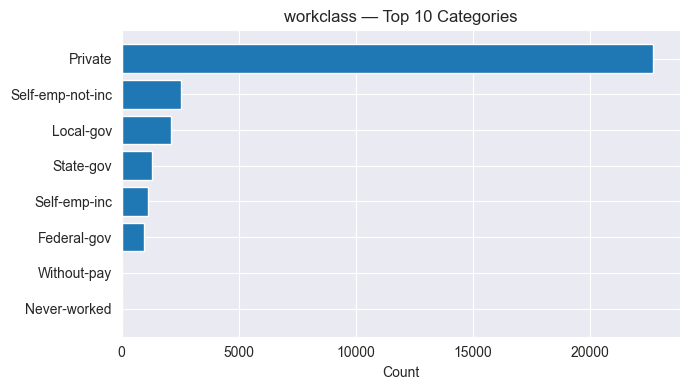

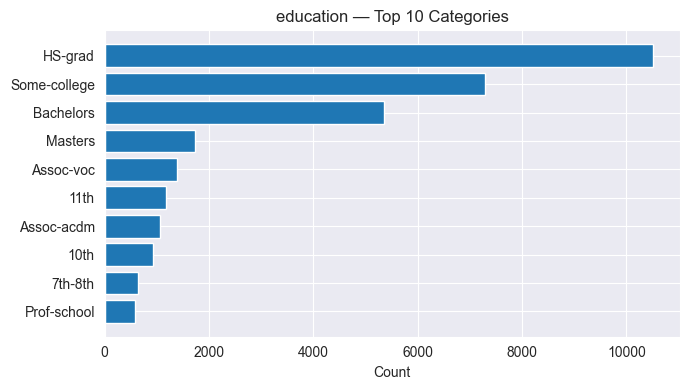

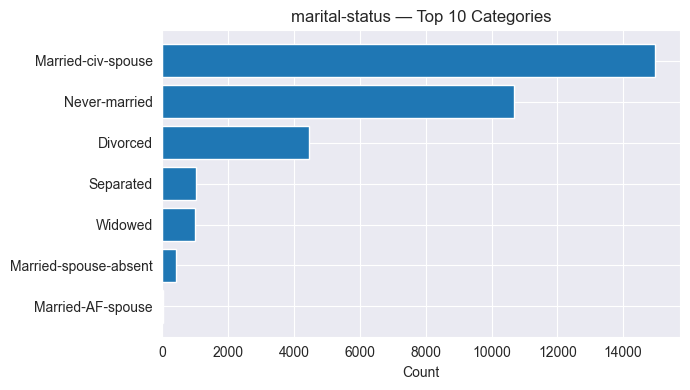

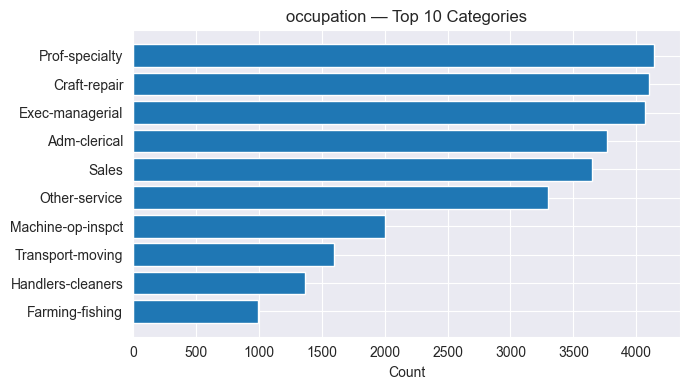

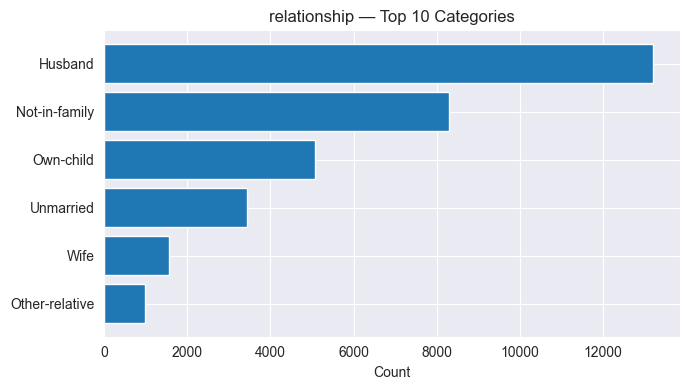

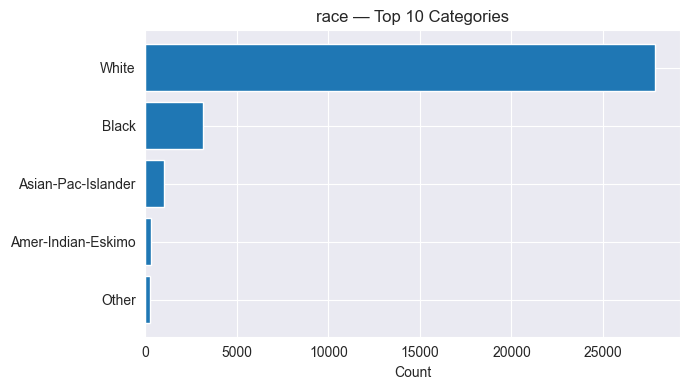

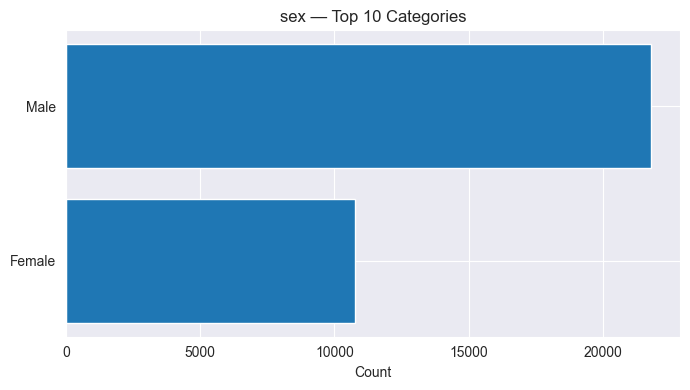

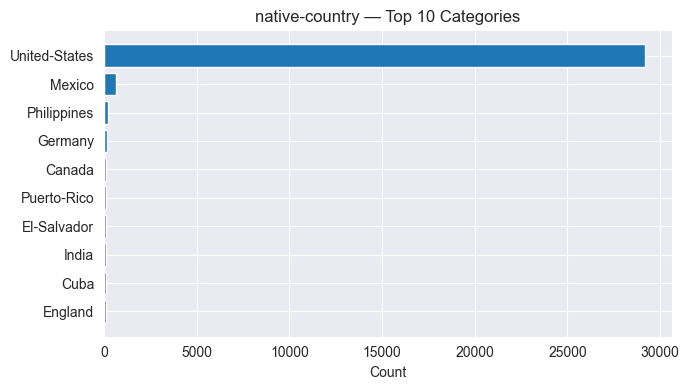

In [9]:
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

for col in cat_cols:
    counts = df[col].value_counts().head(10)
    plt.figure(figsize=(7,4))
    plt.barh(list(counts.index)[::-1], list(counts.values)[::-1])
    plt.title(f'{col} — Top 10 Categories')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

**Why:** Category balance affects encoding and helps spot dominant groups.
**Result:** Most entries are **Private workclass**, **HS-grad/Some-college**, **Married-civ-spouse**, **United-States**, **Male**, **White** - top occupations include professional/managerial roles.

## 9. Correlation - Numerical Features
We examine linear relationships between numerical features to identify redundancy and potential predictors.

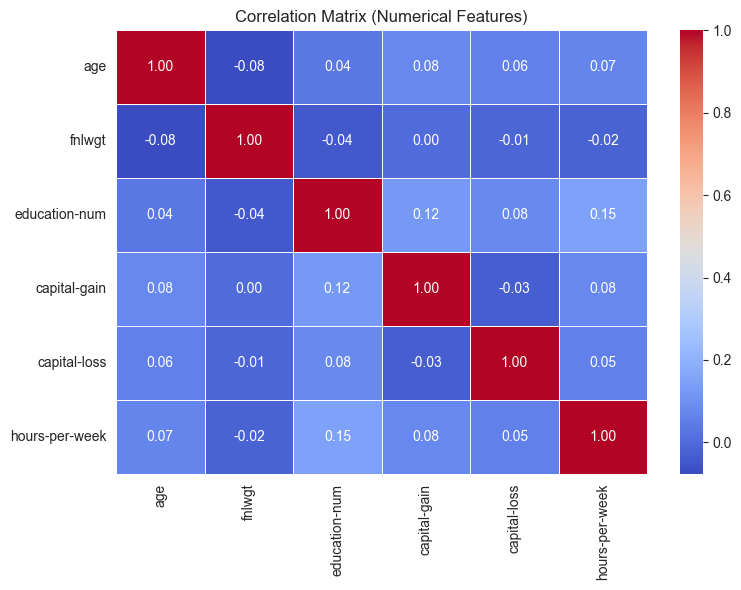

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.show()

**Why:**
Strong correlations could indicate overlapping information, while weak ones suggest independent predictors.

**Result:**
Most correlations are weak (< 0.15) = features are largely independent.
**education-num** has a small positive correlation with hours-per-week (0.15) and capital-gain (0.12) - people with higher education tend to work more and earn more.
**age** slightly correlates with capital-gain (0.08) - older individuals may have more investments.
**fnlwgt** shows near-zero correlations - not predictive, mainly a census sampling weight.
No signs of multicollinearity - all numeric features can be safely used for modeling.

- Interpretation summary:
The dataset’s numeric features are mostly independent, which is good because each contributes unique information.
However, education-num, hours-per-week, and capital-gain stand out as more informative features likely related to higher income.

## 10. Feature vs Target - Numeric
Boxplots compare distributions by income class (≤50K vs >50K).

<Figure size 600x400 with 0 Axes>

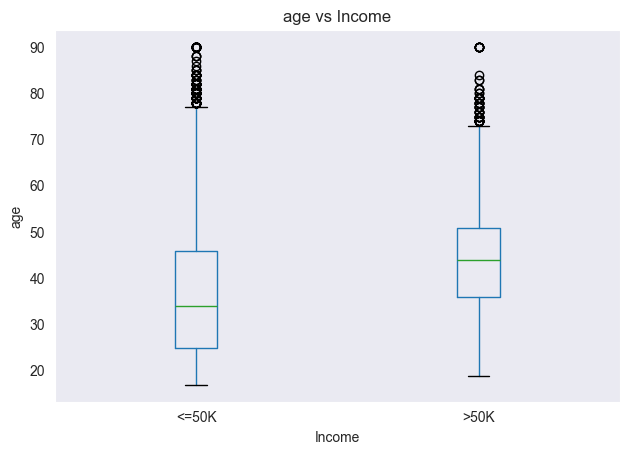

<Figure size 600x400 with 0 Axes>

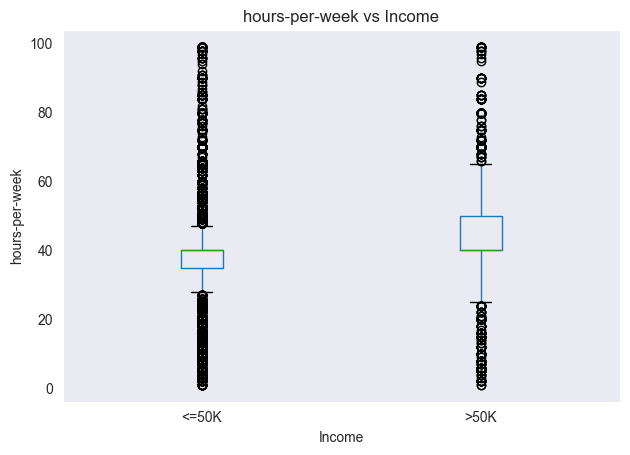

<Figure size 600x400 with 0 Axes>

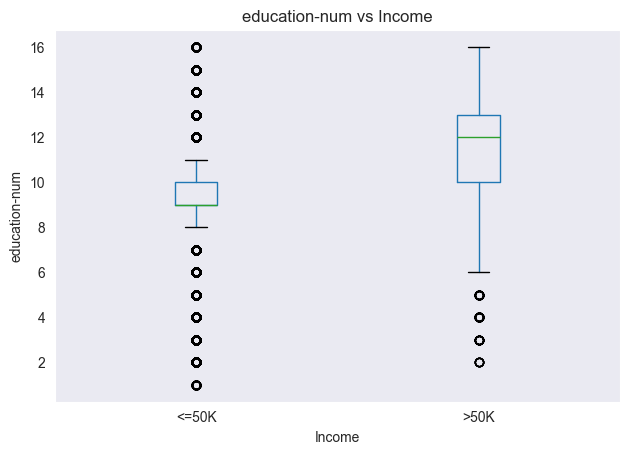

In [11]:
for col in ['age', 'hours-per-week', 'education-num']:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by='income', grid=False)
    plt.title(f'{col} vs Income')
    plt.suptitle('')
    plt.xlabel('Income')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**Result:** Higher **age**, **education-num**, and **hours-per-week** associate with **>50K**.

## 11. EDA Summary & Problem Statement

**Problem Statement:** Predict whether an individual's annual income exceeds \$50K using demographic and work-related features.

**What we learned in EDA (Step 1):**
- **Data shape:** 32,561 rows x 15 columns - 6 numeric - 9 categorical.
- **Missing values:**
        - workclass, occupation, native-country
- **Target imbalance:** ~**76% ≤50K** vs **24% >50K** - to consider class-aware metrics/weights later.
- **Numerical patterns:** `capital-gain/loss` are sparse but informative - **age**, **education-num**, **hours-per-week** likely predictive.
- **Categorical patterns:** Dominant categories include **Private workclass**, **HS-grad / Some-college**, **Married-civ-spouse**, **United-States**, **Male**, **White**.
- **Correlations:** modest overall (not too many insights...) - **fnlwgt** non-predictive and is a census weight (drop later).